In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_utils import (
    download_prices, compute_log_returns,
    compute_annual_stats, compute_correlation_matrix,
    save_data, load_data, ASSET_UNIVERSE
)

In [3]:
prices = download_prices(start="2015-01-01", end="2024-12-31")
log_returns = compute_log_returns(prices)
save_data(prices, log_returns)

print(f"Prices shape:      {prices.shape}")
print(f"Log returns shape: {log_returns.shape}")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"Tickers: {list(prices.columns)}")

Saved to data/
Prices shape:      (2515, 17)
Log returns shape: (2514, 17)
Date range: 2015-01-05 → 2024-12-30
Tickers: ['EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'LQD', 'SPY', 'TLT', 'USO', 'VNQ', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV', 'XLY']


In [8]:
print(type(prices))
print(prices.index[:5])
prices.head()

<class 'pandas.DataFrame'>
DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08'],
              dtype='datetime64[s]', name='Date', freq=None)


Ticker,EEM,EFA,GLD,HYG,IEF,LQD,SPY,TLT,USO,VNQ,XLE,XLF,XLI,XLK,XLP,XLV,XLY
Date,,,,,,,,,,,,,,,,,
2015-01-02,30.355053,43.780632,114.080002,49.303200,83.141495,81.027054,170.125000,93.712074,159.119995,52.549870,25.548052,16.274790,46.211407,18.084276,35.865395,57.057842,31.636641
2015-01-05,29.814819,42.747181,115.800003,48.846466,83.648819,81.358391,167.052658,95.184128,150.320007,52.837482,24.491190,15.932574,45.131962,17.808208,35.613182,56.766850,31.031567
2015-01-06,29.689541,42.262974,117.120003,48.659363,84.210732,81.689743,165.479126,96.899117,144.399994,53.361572,24.131401,15.689083,44.575878,17.593498,35.568687,56.575645,30.722397
2015-01-07,30.331568,42.732719,116.430000,48.962017,84.195084,81.797935,167.541214,96.707748,146.960007,54.179668,24.182808,15.853601,44.911148,17.742476,36.176952,57.905834,31.208246
2015-01-08,30.848322,43.310879,115.940002,49.330673,83.851738,81.534172,170.514252,95.427017,148.399994,54.384197,24.725687,16.090521,45.810699,18.132475,36.725872,58.895187,31.676401


In [4]:
mean_returns, volatilities = compute_annual_stats(log_returns)

stats = pd.DataFrame({
    "Annual Return": mean_returns.round(4),
    "Annual Volatility": volatilities.round(4),
    "Sharpe (approx)": (mean_returns / volatilities).round(4)
})
stats["Label"] = stats.index.map(ASSET_UNIVERSE)
print(stats.sort_values("Sharpe (approx)", ascending=False).to_string())

        Annual Return  Annual Volatility  Sharpe (approx)               Label
Ticker                                                                       
XLK            0.1866             0.2336           0.7989                Tech
SPY            0.1229             0.1768           0.6951             S&P 500
XLY            0.1266             0.2131           0.5938      Consumer Disc.
GLD            0.0748             0.1413           0.5296                Gold
XLI            0.1035             0.1970           0.5254         Industrials
XLP            0.0751             0.1467           0.5119    Consumer Staples
XLV            0.0858             0.1678           0.5114          Healthcare
XLF            0.1071             0.2225           0.4813          Financials
HYG            0.0396             0.0854           0.4635          High Yield
EFA            0.0512             0.1738           0.2948      Intl Developed
LQD            0.0223             0.0860           0.2595       

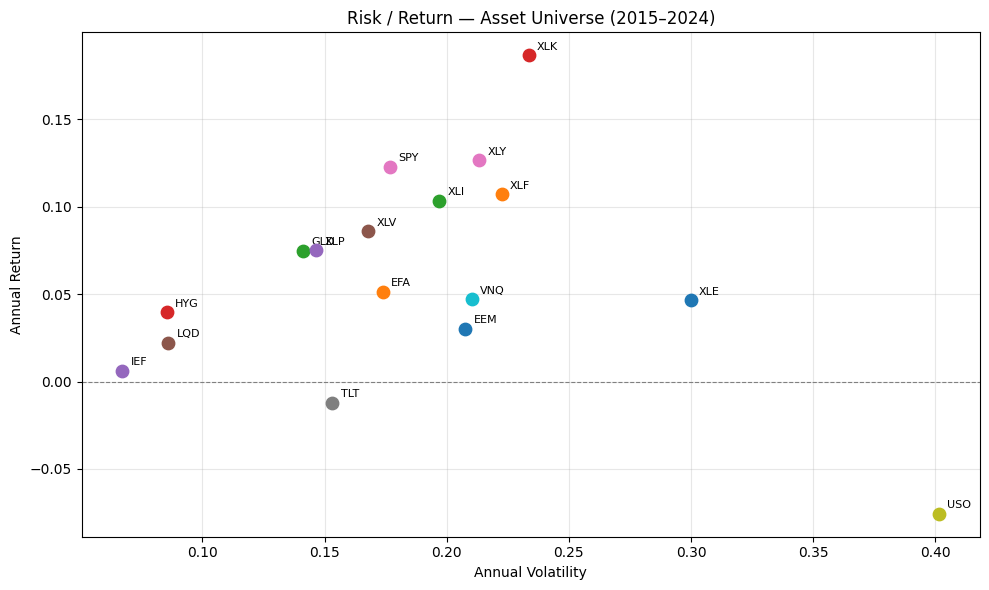

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

for ticker in mean_returns.index:
    ax.scatter(volatilities[ticker], mean_returns[ticker], s=80, zorder=3)
    ax.annotate(ticker, (volatilities[ticker], mean_returns[ticker]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Annual Volatility")
ax.set_ylabel("Annual Return")
ax.set_title("Risk / Return — Asset Universe (2015–2024)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("data/risk_return_scatter.png", dpi=150)
plt.show()

We can already see the shape of the future efficient frontier. SPY sits in a reasonable spot, but notice that a combination of IEF/GLD (low volatility, low-but-positive return) with XLK could theoretically produce a portfolio above SPY on the return axis with less risk. 

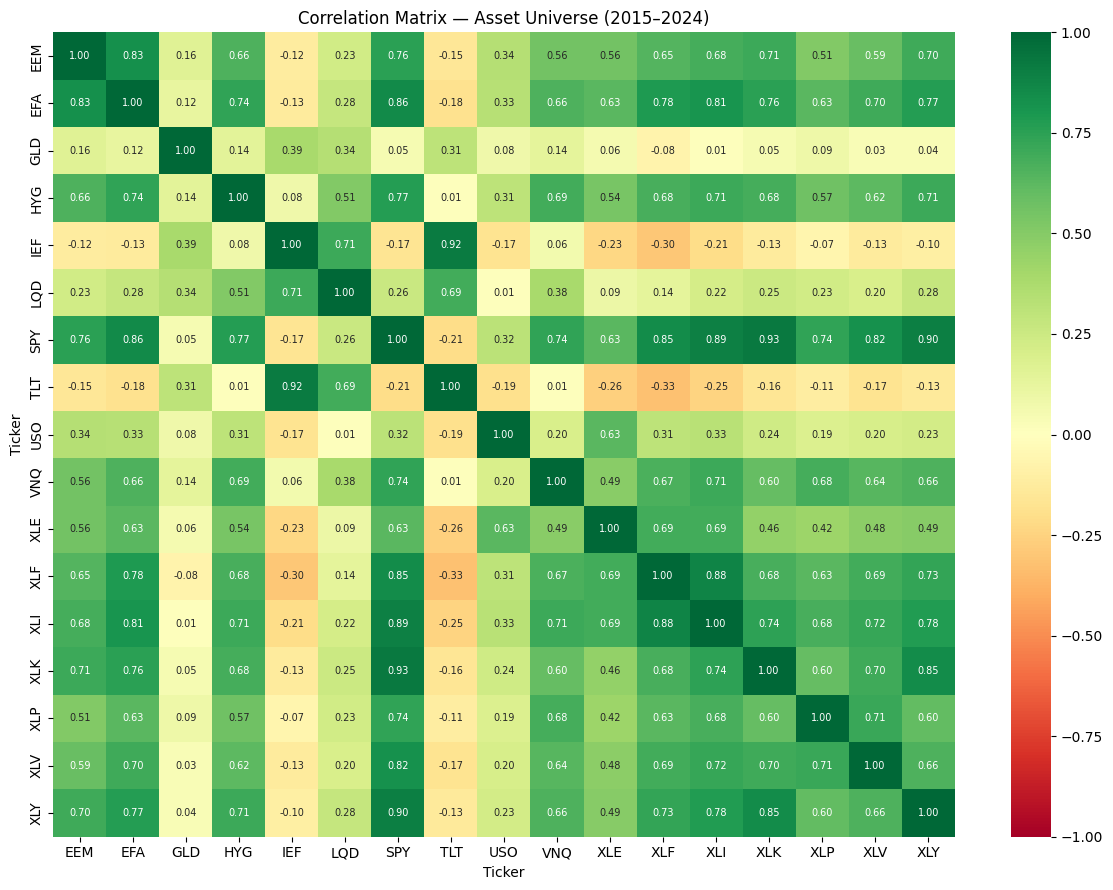

In [6]:
corr = compute_correlation_matrix(log_returns)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={"size": 7})
ax.set_title("Correlation Matrix — Asset Universe (2015–2024)")
plt.tight_layout()
plt.savefig("data/correlation_heatmap.png", dpi=150)
plt.show()

All US sector ETFs (XLK, XLF, XLI…) are dark green with each other and with SPY — correlations of 0.7–0.93. They move almost in lockstep.
IEF and TLT are orange/red against equities (−0.10 to −0.30) — these are your true diversifiers, they go up when stocks fall.
GLD is nearly white everywhere — almost uncorrelated with everything, which makes it a powerful portfolio stabilizer.
USO is weakly correlated with most assets — useful but very volatile.